In [1]:
# Paths and OS utilities
import os
import sys
# Pickle kept for compatibility with older notebooks
import pickle

# Data + arrays
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm          # colormaps
import matplotlib.colors as colors  # color normalization
import matplotlib.patches as patches # rectangles for figure backgrounds
import seaborn as sns
from matplotlib import font_manager as fm
from pathlib import Path


def set_figure_defaults(font_family=None):
    """Matplotlib defaults for compact, paper-style plots."""
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['axes.linewidth'] = 0.5
    plt.rcParams['xtick.major.width'] = 0.5
    plt.rcParams['xtick.minor.width'] = 0.5
    plt.rcParams['ytick.major.width'] = 0.5
    plt.rcParams['ytick.minor.width'] = 0.5
    plt.rcParams['xtick.major.size'] = 2
    plt.rcParams['xtick.minor.size'] = 1.5
    plt.rcParams['ytick.major.size'] = 2
    plt.rcParams['ytick.minor.size'] = 1.5
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['axes.labelsize'] = 8
    plt.rcParams['svg.fonttype'] = 'none'

    if font_family:
        plt.rcParams['font.family'] = font_family


def apply_fig1a_style(font_family=None):
    """Match the Fig1a_cSGD notebook styling (Arial, thicker lines, no top/right spines)."""
    plt.rcParams.update({
        'font.family': font_family or plt.rcParams.get('font.family'),
        'axes.edgecolor': 'black',
        'axes.linewidth': 2.0,
        'lines.linewidth': 2.6,
        'xtick.major.width': 1.8,
        'ytick.major.width': 1.8,
        'xtick.minor.width': 1.0,
        'ytick.minor.width': 1.0,
        'xtick.major.size': 6,
        'ytick.major.size': 6,
        'xtick.minor.size': 3,
        'ytick.minor.size': 3,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
        'figure.titlesize': 14,
        'axes.spines.top': True,
        'axes.spines.right': True,
    })
    
def apply_fig1a_style_box(font_family=None):
    """Match the Fig1a_cSGD notebook styling (Arial, thicker lines, no top/right spines)."""
    plt.rcParams.update({
        'font.family': font_family or plt.rcParams.get('font.family'),
        'axes.edgecolor': 'black',
        'axes.linewidth': 2.0,
        'lines.linewidth': 2.6,
        'xtick.major.width': 1.8,
        'ytick.major.width': 1.8,
        'xtick.minor.width': 1.0,
        'ytick.minor.width': 1.0,
        'xtick.major.size': 6,
        'ytick.major.size': 6,
        'xtick.minor.size': 3,
        'ytick.minor.size': 3,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
        'figure.titlesize': 14,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

def fig1a_despine(ax=None, offset=2, trim=True):
    """Seaborn-like despine matching Fig1a defaults."""
    try:
        sns.despine(ax=ax, offset=offset, trim=trim)
    except Exception:
        # If seaborn isn't available, hide top/right spines manually.
        if ax is None:
            ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


def render_background(fig, color="#00000010"):
    """Add a light background rectangle to the figure."""
    rect = patches.Rectangle((0, 0), 1, 1, transform=fig.transFigure, color=color, zorder=-1, linewidth=0)
    fig.patches.append(rect)

def normalize_cmap(X, ref):
    """Normalize X by the max absolute value in ref (shared heatmap scale)."""
    ref = np.abs(ref)
    X = np.abs(X)
    X = X / max(ref)
    return X

# Register local Arial if present (not automatically discovered by Matplotlib).
def register_local_font():
    candidates = [Path("arial.ttf"), Path("mod_cog_dsa") / "arial.ttf"]
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidates.append(parent / "mod_cog_dsa" / "arial.ttf")

    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        if path.exists():
            fm.fontManager.addfont(str(path))
            name = fm.FontProperties(fname=str(path)).get_name()
            try:
                fm.findfont(name, fallback_to_default=False)
                return [name]
            except Exception:
                pass
    return ["DejaVu Sans"]

font_family = register_local_font()

# Apply defaults immediately
set_figure_defaults(font_family=font_family)

apply_fig1a_style(font_family=font_family)

# Show which font family was selected (useful when running on different machines).
print(f"Matplotlib font.family: {plt.rcParams.get('font.family')}")

%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2


Matplotlib font.family: ['Arial']


In [ ]:
# Load DSA pairwise distances for mod_cog (EG/GD).
# Assumes ./stats/dsa.h5 with columns like model_a/b, task_a/b, seed_a/b, dsa.
df = pd.read_hdf(os.path.join(".", "stats", "dsa.h5"))

os.makedirs("figs", exist_ok=True)

# Unique id for seed pairs (occasionally useful for grouping/debugging).
df["seed_ab"] = df.apply(lambda row: str(row["seed_a"]) + str(row["seed_b"]), axis=1)


In [3]:
def make_comparison_matrix(df, metric, model_order=None, task_order=None):
    """Turn long-form pairwise distances into a square matrix.
    Rows/cols ordered as model -> task -> seed.
    """
    # Determine order (defaults derived from data)
    model_order = model_order or sorted(set(df['model_a']).union(df['model_b']))
    all_seeds = sorted(set(df['seed_a']).union(df['seed_b']))
    task_order = task_order or sorted(set(df['task_a']).union(df['task_b']))

    # Flat list of (model, task, seed) labels
    ordered_pairs = [(m, t, s) for m in model_order for t in task_order for s in all_seeds]

    pair_to_idx = {pair: idx for idx, pair in enumerate(ordered_pairs)}
    n = len(pair_to_idx)

    # Lower-triangular matrix of distances (upper left as NaN)
    mat = np.full((n, n), np.nan)

    for _, row in df.iterrows():
        a = (row['model_a'], row['task_a'], row['seed_a'])
        b = (row['model_b'], row['task_b'], row['seed_b'])

        if a in pair_to_idx and b in pair_to_idx:
            i, j = min(pair_to_idx[a], pair_to_idx[b]), max(pair_to_idx[a], pair_to_idx[b])
            mat[i, j] = np.nan
            mat[j, i] = row[metric]

    mat_df = pd.DataFrame(mat, index=ordered_pairs, columns=ordered_pairs)
    return mat_df

dsa = make_comparison_matrix(df, metric="dsa", model_order=["gd", "eg"])


In [4]:
# Use full dataset (optionally filter here).
filtered_df = df

# Order models as GD then EG in the matrix.
order = ["gd", "eg"]

# Pairwise DSA matrix for plotting.
dsa = make_comparison_matrix(filtered_df, metric="dsa", model_order=order)


In [5]:
# Task-wise EG vs GD distance as 1D colored bars (original + sorted + per-seed).
if 'dsa' not in globals():
  raise RuntimeError("Run the DSA matrix cell first.")

# Derive task/seed order from the GD block to preserve ordering.
if 'task_order' in globals() and 'all_seeds' in globals():
  task_order_local = task_order
  seed_order_local = all_seeds
else:
  gd_pairs = [p for p in dsa.index if p[0] == 'gd']
  task_order_local = []
  seed_order_local = []
  for _, t, s in gd_pairs:
    if t not in task_order_local:
      task_order_local.append(t)
    if s not in seed_order_local:
      seed_order_local.append(s)

pair_to_idx = {pair: i for i, pair in enumerate(dsa.index)}

means = []
per_seed = np.full((len(seed_order_local), len(task_order_local)), np.nan)
for ti, t in enumerate(task_order_local):
  vals = []
  for si, s in enumerate(seed_order_local):
    p = ('eg', t, s)
    q = ('gd', t, s)
    if p in pair_to_idx and q in pair_to_idx:
      i = pair_to_idx[p]
      j = pair_to_idx[q]
      v = dsa.values[i, j]
      if np.isnan(v):
        v = dsa.values[j, i]
      if not np.isnan(v):
        vals.append(v)
        per_seed[si, ti] = v
  means.append(np.mean(vals) if vals else np.nan)

means = np.array(means)


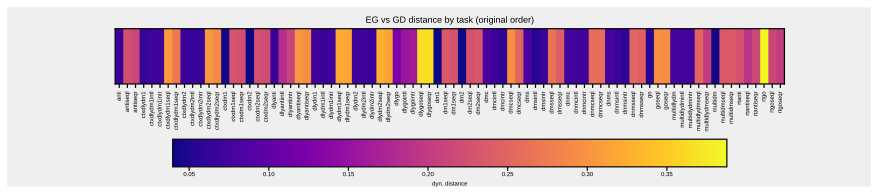

In [6]:
# Version 1: original task order.
fig, ax = plt.subplots(figsize=(12, 2.5), dpi=300)
render_background(fig)

im = ax.imshow(means[np.newaxis, :], aspect='auto', cmap='plasma')
ax.set_yticks([])
ax.set_xticks(np.arange(len(task_order_local)))
ax.set_xticklabels(task_order_local, rotation=90, fontsize=6)
ax.set_title('EG vs GD distance by task (original order)', fontsize=9)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.2, pad=0.4)
cbar.set_label('dyn. distance', fontsize=6)
cbar.ax.tick_params(labelsize=6, pad=1)


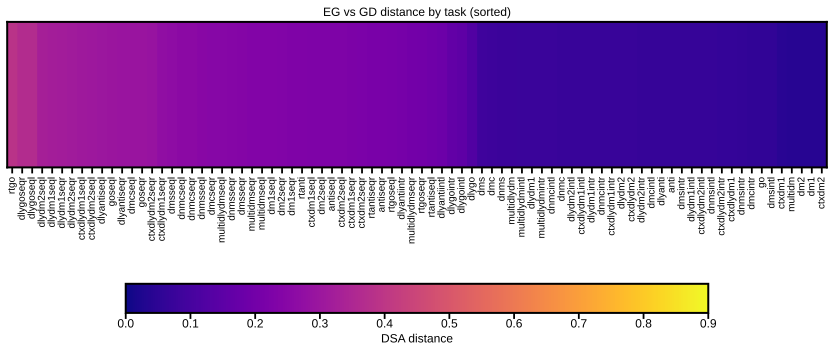

In [ ]:
# Version 2: sorted by distance (descending).
valid_mask = ~np.isnan(means)
sorted_idx = np.argsort(means[valid_mask])[::-1]

sorted_means = means[valid_mask][sorted_idx]
sorted_tasks = np.array(task_order_local)[valid_mask][sorted_idx]

fig, ax = plt.subplots(figsize=(11.69, 5), dpi=300)
fig.subplots_adjust(left=0.08, right=0.98, top=0.94, bottom=0.28)
# 
im = ax.imshow(sorted_means[np.newaxis, :], aspect='auto', cmap='plasma', vmin=0.0, vmax=0.9)
ax.set_yticks([])
ax.set_xticks(np.arange(len(sorted_tasks)))
ax.set_xticklabels(sorted_tasks, rotation=90, fontsize=10)
ax.set_title('EG vs GD distance by task (sorted)', fontsize=12)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.1, pad=0.4)
cbar.set_label('DSA distance', fontsize=12)
cbar.ax.tick_params(labelsize=12, pad=0)
plt.savefig('figs/mod_cog_dsa_sorted_colorbar.pdf', bbox_inches='tight', transparent=True)
plt.savefig('figs/mod_cog_dsa_sorted_colorbar.svg', bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

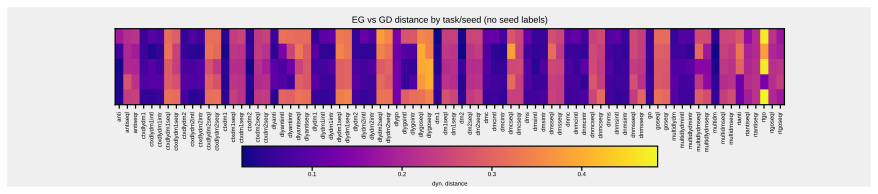

In [8]:
# Version 3: per-seed bars (no seed labels, keep task labels).
fig_height = max(2.5, 0.25 * len(seed_order_local))
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
render_background(fig)

im = ax.imshow(per_seed, aspect='auto', cmap='plasma')
ax.set_yticks([])
ax.set_xticks(np.arange(len(task_order_local)))
ax.set_xticklabels(task_order_local, rotation=90, fontsize=6)
ax.set_title('EG vs GD distance by task/seed (no seed labels)', fontsize=9)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.15, pad=0.3)
cbar.set_label('dyn. distance', fontsize=6)
cbar.ax.tick_params(labelsize=6, pad=1)


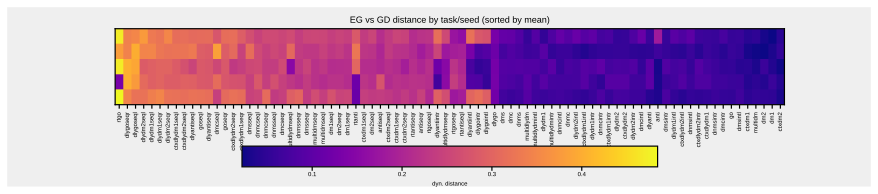

In [9]:
# Version 4: per-seed bars, tasks sorted by mean distance.
valid_mask = ~np.isnan(means)
sorted_idx = np.argsort(means[valid_mask])[::-1]

sorted_tasks = np.array(task_order_local)[valid_mask][sorted_idx]
per_seed_sorted = per_seed[:, valid_mask][:, sorted_idx]

fig_height = max(2.5, 0.25 * len(seed_order_local))
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
render_background(fig)

im = ax.imshow(per_seed_sorted, aspect='auto', cmap='plasma')
ax.set_yticks([])
ax.set_xticks(np.arange(len(sorted_tasks)))
ax.set_xticklabels(sorted_tasks, rotation=90, fontsize=6)
ax.set_title('EG vs GD distance by task/seed (sorted by mean)', fontsize=9)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.15, pad=0.3)
cbar.set_label('dyn. distance', fontsize=6)
cbar.ax.tick_params(labelsize=6, pad=1)


Figure size: 18 x 2.5


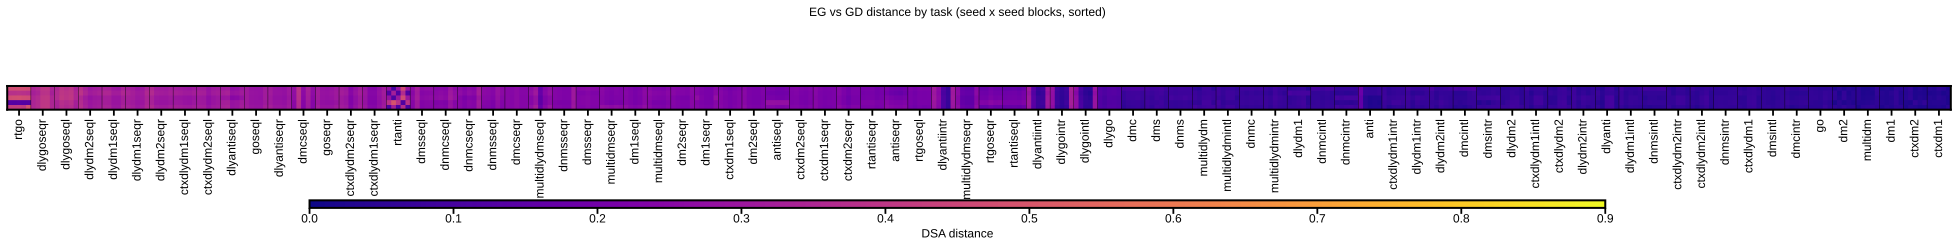

In [ ]:
# Version 5: inter-seed EG vs GD (seed x seed) blocks per task (sorted by mean distance).
# Build a block matrix of shape (num_seeds, num_seeds * num_tasks) with gaps between tasks.
block_w = len(seed_order_local)
gap = 0

# Compute task means to sort.
task_means = []
for t in task_order_local:
  vals = []
  for s1 in seed_order_local:
    for s2 in seed_order_local:
      p = ('eg', t, s1)
      q = ('gd', t, s2)
      if p in pair_to_idx and q in pair_to_idx:
        ii = pair_to_idx[p]
        jj = pair_to_idx[q]
        v = dsa.values[ii, jj]
        if np.isnan(v):
          v = dsa.values[jj, ii]
        if not np.isnan(v):
          vals.append(v)
  task_means.append(np.mean(vals) if vals else np.nan)

order_idx = np.argsort(np.array(task_means))[::-1]
sorted_tasks = [task_order_local[i] for i in order_idx]

num_tasks_local = len(sorted_tasks)
block = np.full((len(seed_order_local), num_tasks_local * block_w + (num_tasks_local - 1) * gap), np.nan)

for ti, t in enumerate(sorted_tasks):
  base = ti * (block_w + gap)
  for i, s1 in enumerate(seed_order_local):
    for j, s2 in enumerate(seed_order_local):
      p = ('eg', t, s1)
      q = ('gd', t, s2)
      if p in pair_to_idx and q in pair_to_idx:
        ii = pair_to_idx[p]
        jj = pair_to_idx[q]
        v = dsa.values[ii, jj]
        if np.isnan(v):
          v = dsa.values[jj, ii]
        if not np.isnan(v):
          block[i, base + j] = v

fig_height = max(2.5, 0.25 * len(seed_order_local))
fig_width = fig_height * (num_tasks_local * block_w) / max(len(seed_order_local), 1)
fig_width = min(18, max(10, fig_width))
print(f"Figure size: {fig_width} x {fig_height}")
fig = plt.figure(figsize=(30, 3), dpi=400)

# Make the image fill more of the figure
ax = fig.add_axes([0.06, 0.22, 0.90, 0.68])  # [left, bottom, width, height]

im = ax.imshow(block, aspect='equal', cmap='plasma', vmin=0.0, vmax=0.9)

# Task labels at block centers.
centers = [ti * (block_w + gap) + (block_w - 1) / 2 for ti in range(num_tasks_local)]
ax.set_xticks(centers)
ax.set_xticklabels(sorted_tasks, rotation=90, fontsize=12)
ax.set_yticks([])
fig.suptitle('EG vs GD distance by task (seed x seed blocks, sorted)', fontsize=12, y=0.98)

# Block separators.
for ti in range(1, num_tasks_local):
  ax.axvline(ti * (block_w + gap) - 0.5, color='black', lw=0.4)

# Colorbar in its own axis below the image
cax = fig.add_axes([0.2, 0.05, 0.6, 0.035])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('DSA distance', fontsize=12)
cbar.ax.tick_params(labelsize=12, pad=0)
plt.savefig('figs/mod_cog_dsa_block_colorbar.pdf', bbox_inches='tight', transparent=True)
plt.savefig('figs/mod_cog_dsa_block_colorbar.svg', bbox_inches='tight', transparent=True)
plt.show()

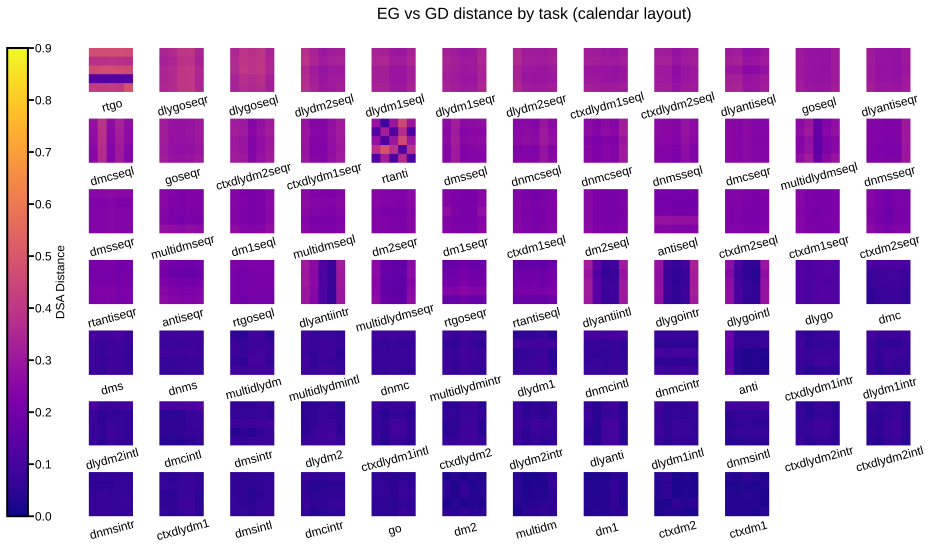

In [ ]:
# Version 5c: inter-seed EG vs GD blocks in a 2D calendar layout (sorted by mean distance).
# Each task is a seed x seed block, arranged in a grid to avoid a long strip.

if 'dsa' not in globals():
  raise RuntimeError("Run the DSA matrix cell first.")

# Ensure task/seed info.
if 'task_order_local' in globals() and 'seed_order_local' in globals():
  _task_order_local = task_order_local
  _seed_order_local = seed_order_local
else:
  gd_pairs = [p for p in dsa.index if p[0] == 'gd']
  _task_order_local = []
  _seed_order_local = []
  for _, t, s in gd_pairs:
    if t not in _task_order_local:
      _task_order_local.append(t)
    if s not in _seed_order_local:
      _seed_order_local.append(s)

pair_to_idx = {pair: i for i, pair in enumerate(dsa.index)}

# Compute task means to sort (same as Version 5).
task_means = []
for t in _task_order_local:
  vals = []
  for s1 in _seed_order_local:
    for s2 in _seed_order_local:
      p = ('eg', t, s1)
      q = ('gd', t, s2)
      if p in pair_to_idx and q in pair_to_idx:
        ii = pair_to_idx[p]
        jj = pair_to_idx[q]
        v = dsa.values[ii, jj]
        if np.isnan(v):
          v = dsa.values[jj, ii]
        if not np.isnan(v):
          vals.append(v)
  task_means.append(np.mean(vals) if vals else np.nan)

order_idx = np.argsort(np.array(task_means))[::-1]
sorted_tasks = [_task_order_local[i] for i in order_idx]

num_tasks_local = len(sorted_tasks)
block_w = len(_seed_order_local)
gap_y = 3  # vertical gap (room for labels)
gap_x = 3  # horizontal gap between columns

# Choose a near-square grid; allow remainder.
ncols = min(12, num_tasks_local)
nrows = int(np.ceil(num_tasks_local / ncols))

H = nrows * block_w + (nrows - 1) * gap_y
W = ncols * block_w + (ncols - 1) * gap_x
grid = np.full((H, W), np.nan)

# Fill blocks.
for ti, t in enumerate(sorted_tasks):
  r = ti // ncols
  c = ti % ncols
  r0 = r * (block_w + gap_y)
  c0 = c * (block_w + gap_x)
  for i, s1 in enumerate(_seed_order_local):
    for j, s2 in enumerate(_seed_order_local):
      p = ('eg', t, s1)
      q = ('gd', t, s2)
      if p in pair_to_idx and q in pair_to_idx:
        ii = pair_to_idx[p]
        jj = pair_to_idx[q]
        v = dsa.values[ii, jj]
        if np.isnan(v):
          v = dsa.values[jj, ii]
        if not np.isnan(v):
          grid[r0 + i, c0 + j] = v

# Plot (A4 landscape, wider).
fig = plt.figure(figsize=(16.0*1.5, 8.27*1.5), dpi=300)
fig.set_facecolor("white")
# Dynamic axes sizing to minimize internal whitespace (left-aligned)
ratio = W / H if H > 0 else 1.0
left, bottom = 0.02, 0.08
avail_w, avail_h = 0.92, 0.86
# Fit axes to data aspect ratio
if avail_w / avail_h > ratio:
  height = avail_h
  width = height * ratio
else:
  width = avail_w
  height = width / ratio
ax = fig.add_axes([left, bottom, width, height])

cmap = mpl.colormaps.get_cmap('plasma').copy()
cmap.set_bad('white')
im = ax.imshow(grid, aspect='equal', cmap=cmap, vmin=0.0, vmax=0.9)

ax.set_xticks([])
ax.set_yticks([])
# remove all spines
for spine in ax.spines.values():
  spine.set_visible(False)

# Task labels below each block.
for ti, t in enumerate(sorted_tasks):
  r = ti // ncols
  c = ti % ncols
  r0 = r * (block_w + gap_y)
  c0 = c * (block_w + gap_x)
  ax.text(c0 + (block_w - 1) / 2, r0 + block_w + 0.5, t,
          fontsize=12, color='black', ha='center', va='top', rotation=15, rotation_mode='anchor')

# Colorbar
cax = fig.add_axes([left+0.175, bottom, 0.012, height])
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
cbar.set_label('DSA Distance', fontsize=12)
cbar.ax.tick_params(labelsize=12, pad=1)

fig.suptitle('EG vs GD distance by task (calendar layout)', fontsize=16, y=0.65)

# Save
out_dir = Path('figs')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'eg_vs_gd_seed_blocks_calendar.pdf', bbox_inches='tight', transparent=True)
fig.savefig(out_dir / 'eg_vs_gd_seed_blocks_calendar.svg', bbox_inches='tight')


In [36]:
# Split the DSA matrix into within-algorithm blocks and show
# (1) original task/seed order and (2) hierarchical task clustering.
task_order = sorted(set(filtered_df['task_a']).union(filtered_df['task_b']))
all_seeds = sorted(set(filtered_df['seed_a']).union(filtered_df['seed_b']))
num_tasks = len(task_order)
num_seeds = len(all_seeds)
num_per_model = num_tasks * num_seeds

ref_seed = 5 if 5 in all_seeds else all_seeds[0]
label_fontsize = 4

# Upper-left (GD) and lower-right (EG) blocks.
gd_block = dsa.iloc[:num_per_model, :num_per_model]
eg_block = dsa.iloc[num_per_model:, num_per_model:]

def symmetrize(mat):
  mat = mat.copy()
  mat = np.where(np.isnan(mat), mat.T, mat)
  np.fill_diagonal(mat, 0.0)
  return mat

gd_mat = symmetrize(gd_block.values)
eg_mat = symmetrize(eg_block.values)

# Task labels at a single seed to reduce clutter, reordered by the given index order.
def task_ticks(block_index, order, seed):
  labels = [t if s == seed else "" for (_, t, s) in block_index]
  labels = [labels[i] for i in order]
  ticks = [i for i, lab in enumerate(labels) if lab]
  ticklabels = [labels[i] for i in ticks]
  return ticks, ticklabels

# Shared plot helper.
def plot_triangle(ax, mat, order, title, ticks, ticklabels):
  mat = mat[np.ix_(order, order)]
  mask = np.triu(np.ones_like(mat, dtype=bool), k=1) 
  mat_masked = np.ma.array(mat, mask=mask)
  im = ax.imshow(mat_masked, cmap=tri_cmap, vmin=vmin, vmax=vmax)
  ax.set_title(title, fontsize=8)
  ax.set_xticks([])
  ax.set_yticks(ticks)
  ax.set_yticklabels(ticklabels, va='top', fontsize=label_fontsize)
  ax.tick_params(axis='y', length=0)
  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
  return im


/tmp/ipykernel_119816/1271781959.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tri_cmap = mpl.cm.get_cmap('plasma').copy()


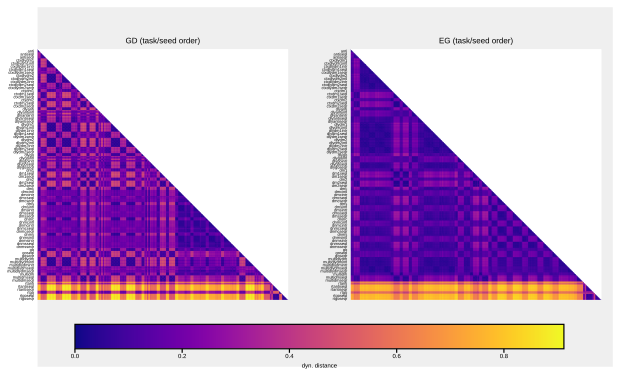

In [37]:
vmin = 0.0
vmax = max(np.nanmax(gd_mat), np.nanmax(eg_mat))

tri_cmap = mpl.cm.get_cmap('plasma').copy()
tri_cmap.set_bad('white')

# Version 1: original order (model -> task -> seed).
order_base = np.arange(num_per_model)

gd_ticks, gd_ticklabels = task_ticks(gd_block.index, order_base, ref_seed)
eg_ticks, eg_ticklabels = task_ticks(eg_block.index, order_base, ref_seed)

fig, axs = plt.subplots(1, 2, figsize=(8, 5), dpi=300)
render_background(fig)
fig.subplots_adjust(left=0.0, right=0.98, top=0.9, bottom=0.05, wspace=0.25)

im0 = plot_triangle(axs[0], gd_mat, order_base, "GD (task/seed order)", gd_ticks, gd_ticklabels)
im1 = plot_triangle(axs[1], eg_mat, order_base, "EG (task/seed order)", eg_ticks, eg_ticklabels)

cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.08, pad=0.08)
cbar.set_label("dyn. distance", fontsize=6)
cbar.ax.tick_params(labelsize=6, pad=1)


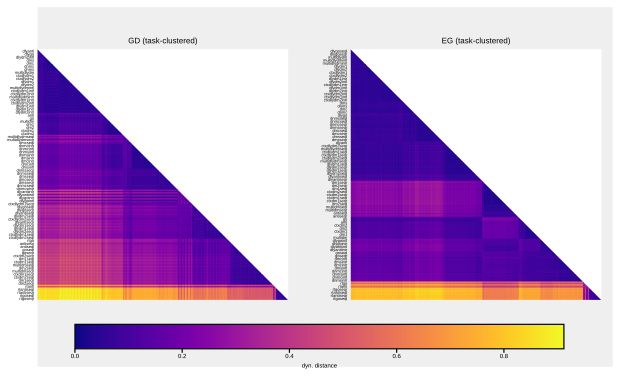

In [14]:

# Version 2: hierarchical clustering at the task level, seeds kept in order within tasks.
try:
  from scipy.cluster.hierarchy import linkage, leaves_list
  from scipy.spatial.distance import squareform
  have_scipy = True
except ImportError:
  have_scipy = False

if not have_scipy:
  print("scipy not installed; skipping clustered version")
else:
  def task_level_order(mat):
    mat4 = mat.reshape(num_tasks, num_seeds, num_tasks, num_seeds)
    task_mat = np.nanmean(mat4, axis=(1, 3))
    dist = squareform(task_mat, checks=False)
    Z = linkage(dist, method="average")
    task_leaves = leaves_list(Z)
    order = []
    for t in task_leaves:
      for s in range(num_seeds):
        order.append(t * num_seeds + s)
    return np.array(order)

  gd_order = task_level_order(gd_mat)
  eg_order = task_level_order(eg_mat)

  gd_ticks, gd_ticklabels = task_ticks(gd_block.index, gd_order, ref_seed)
  eg_ticks, eg_ticklabels = task_ticks(eg_block.index, eg_order, ref_seed)

  fig, axs = plt.subplots(1, 2, figsize=(8, 5), dpi=300)
  render_background(fig)
  fig.subplots_adjust(left=0.0, right=0.98, top=0.9, bottom=0.05, wspace=0.25)

  im0 = plot_triangle(axs[0], gd_mat, gd_order, "GD (task-clustered)", gd_ticks, gd_ticklabels)
  im1 = plot_triangle(axs[1], eg_mat, eg_order, "EG (task-clustered)", eg_ticks, eg_ticklabels)

  cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.08, pad=0.08)
  cbar.set_label("dyn. distance", fontsize=6)
  cbar.ax.tick_params(labelsize=6, pad=1)


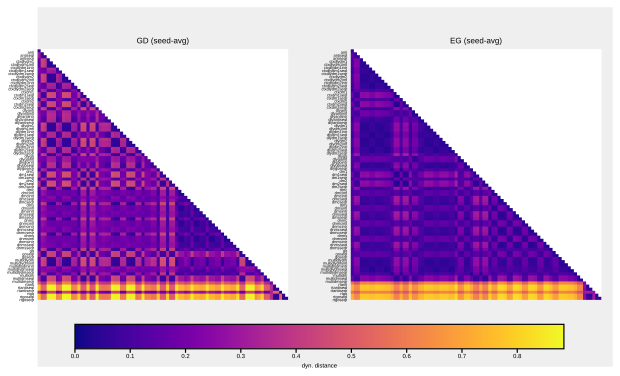

In [15]:
# Version 3: seed-averaged (task-level) triangles.
mat4_gd = gd_mat.reshape(num_tasks, num_seeds, num_tasks, num_seeds)
mat4_eg = eg_mat.reshape(num_tasks, num_seeds, num_tasks, num_seeds)

gd_task = np.nanmean(mat4_gd, axis=(1, 3))
eg_task = np.nanmean(mat4_eg, axis=(1, 3))

vmin_task = 0.0
vmax_task = max(np.nanmax(gd_task), np.nanmax(eg_task))

fig, axs = plt.subplots(1, 2, figsize=(8, 5), dpi=300)
render_background(fig)
fig.subplots_adjust(left=0.0, right=0.98, top=0.9, bottom=0.05, wspace=0.25)

def plot_task_triangle(ax, mat, title):
  mask = np.triu(np.ones_like(mat, dtype=bool), k=1) 
  mat_masked = np.ma.array(mat, mask=mask)
  im = ax.imshow(mat_masked, cmap=tri_cmap, vmin=vmin_task, vmax=vmax_task)
  ax.set_title(title, fontsize=8)
  ax.set_xticks([])
  ax.set_yticks(np.arange(num_tasks))
  ax.set_yticklabels(task_order, va='top', fontsize=label_fontsize)
  ax.tick_params(axis='y', length=0)
  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
  return im

im0 = plot_task_triangle(axs[0], gd_task, "GD (seed-avg)")
im1 = plot_task_triangle(axs[1], eg_task, "EG (seed-avg)")

cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.08, pad=0.08)
cbar.set_label("dyn. distance", fontsize=6)
cbar.ax.tick_params(labelsize=6, pad=1)


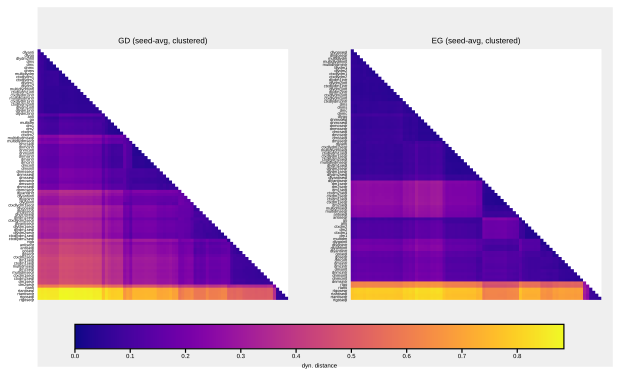

In [16]:
# Version 4: seed-avg task-level clustering (if scipy available).
if have_scipy:
  def cluster_order_task(mat):
    dist = squareform(mat, checks=False)
    Z = linkage(dist, method="average")
    return leaves_list(Z)

  gd_task_order = cluster_order_task(gd_task)
  eg_task_order = cluster_order_task(eg_task)

  gd_task_c = gd_task[np.ix_(gd_task_order, gd_task_order)]
  eg_task_c = eg_task[np.ix_(eg_task_order, eg_task_order)]
  gd_labels_c = [task_order[i] for i in gd_task_order]
  eg_labels_c = [task_order[i] for i in eg_task_order]

  fig, axs = plt.subplots(1, 2, figsize=(8, 5), dpi=300)
  render_background(fig)
  fig.subplots_adjust(left=0.0, right=0.98, top=0.9, bottom=0.05, wspace=0.25)

  def plot_task_triangle_clustered(ax, mat, labels, title):
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1) 
    mat_masked = np.ma.array(mat, mask=mask)
    im = ax.imshow(mat_masked, cmap=tri_cmap, vmin=vmin_task, vmax=vmax_task)
    ax.set_title(title, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, va='top', fontsize=label_fontsize)
    ax.tick_params(axis='y', length=0)
    for spine in ["top", "right", "left", "bottom"]:
      ax.spines[spine].set_visible(False)
    return im

  im0 = plot_task_triangle_clustered(axs[0], gd_task_c, gd_labels_c, "GD (seed-avg, clustered)")
  im1 = plot_task_triangle_clustered(axs[1], eg_task_c, eg_labels_c, "EG (seed-avg, clustered)")

  cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.08, pad=0.08)
  cbar.set_label("dyn. distance", fontsize=6)
  cbar.ax.tick_params(labelsize=6, pad=1)


/tmp/ipykernel_2573951/3866225355.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tri_cmap = mpl.cm.get_cmap('plasma').copy()


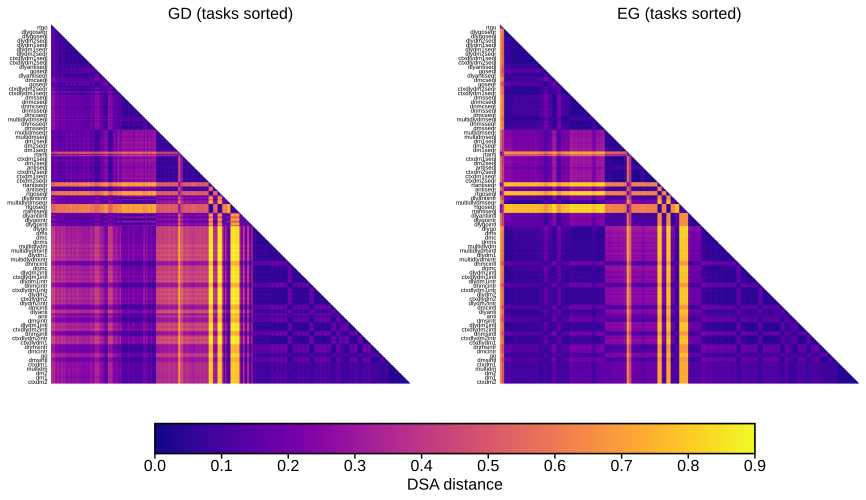

In [ ]:
# Triangles with tasks sorted by EG vs GD mean distance (from 1D bars).
if 'dsa' not in globals():
  raise RuntimeError("Run the DSA matrix cell first.")

# Task/seed order.
if 'task_order' in globals() and 'all_seeds' in globals():
  task_order_local = task_order
  seed_order_local = all_seeds
else:
  gd_pairs = [p for p in dsa.index if p[0] == 'gd']
  task_order_local = []
  seed_order_local = []
  for _, t, s in gd_pairs:
    if t not in task_order_local:
      task_order_local.append(t)
    if s not in seed_order_local:
      seed_order_local.append(s)

pair_to_idx = {pair: i for i, pair in enumerate(dsa.index)}

# Compute EG vs GD mean distance per task (across seeds) to sort tasks.
means = []
for t in task_order_local:
  vals = []
  for s in seed_order_local:
    p = ('gd', t, s)
    q = ('eg', t, s)
    if p in pair_to_idx and q in pair_to_idx:
      i = pair_to_idx[p]
      j = pair_to_idx[q]
      v = dsa.values[i, j]
      if np.isnan(v):
        v = dsa.values[j, i]
      if not np.isnan(v):
        vals.append(v)
  means.append(np.mean(vals) if vals else np.nan)

order_tasks = [t for _, t in sorted(zip(means, task_order_local), key=lambda x: (np.nan_to_num(x[0], nan=-np.inf)), reverse=True)]

num_tasks = len(task_order_local)
num_seeds = len(seed_order_local)

# Map to indices in the GD/EG blocks.
gd_block = dsa.iloc[:num_tasks*num_seeds, :num_tasks*num_seeds]
eg_block = dsa.iloc[num_tasks*num_seeds:, num_tasks*num_seeds:]

idx_map_gd = { (t,s): i for i, (_, t, s) in enumerate(gd_block.index) }
idx_map_eg = { (t,s): i for i, (_, t, s) in enumerate(eg_block.index) }

# Keep only pairs that exist in BOTH blocks to stay aligned.
order_pairs = [(t, s) for t in order_tasks for s in seed_order_local]
order_pairs = [(t, s) for (t, s) in order_pairs if (t, s) in idx_map_gd and (t, s) in idx_map_eg]

order_idx_gd = [idx_map_gd[(t,s)] for (t,s) in order_pairs]
order_idx_eg = [idx_map_eg[(t,s)] for (t,s) in order_pairs]

# Labels at ref seed.
ref_seed = 5 if 5 in seed_order_local else seed_order_local[0]
labels = [t if s == ref_seed else "" for (t, s) in order_pairs]
ticks = [i for i, lab in enumerate(labels) if lab]

# Symmetrize to fill upper triangle values, then mask upper for plotting.
def symmetrize(mat):
  mat = mat.copy()
  mat = np.where(np.isnan(mat), mat.T, mat)
  np.fill_diagonal(mat, 0.0)
  return mat

gd_mat = symmetrize(gd_block.values)
eg_mat = symmetrize(eg_block.values)

fig, axs = plt.subplots(1, 2, figsize=(11.69, 8.27), dpi=300)
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.08, wspace=0.25)

vmin = 0.0
vmax = 0.9
tri_cmap = mpl.cm.get_cmap('plasma').copy()
tri_cmap.set_bad('white')

def plot_triangle_sorted(ax, mat, order_idx, title):
  mat = mat[np.ix_(order_idx, order_idx)]
  mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
  mat_masked = np.ma.array(mat, mask=mask)
  im = ax.imshow(mat_masked, cmap=tri_cmap, vmin=vmin, vmax=vmax)
  ax.set_title(title, fontsize=16)
  ax.set_xticks([])
  ax.set_yticks(ticks)
  ax.set_yticklabels([labels[i] for i in ticks], va='top', fontsize=6)
  ax.tick_params(axis='y', length=0)
  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
  return im

im0 = plot_triangle_sorted(axs[0], gd_mat, order_idx_gd, 'GD (tasks sorted)')
im1 = plot_triangle_sorted(axs[1], eg_mat, order_idx_eg, 'EG (tasks sorted)')

cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.06, pad=0.08)
cbar.set_label('DSA distance', fontsize=16)
cbar.ax.tick_params(labelsize=16, pad=1, which='major')
plt.savefig('figs/mod_cog_dsa_sorted_triangles_colorbar.pdf', bbox_inches='tight', transparent=True)
plt.savefig('figs/mod_cog_dsa_sorted_triangles_colorbar.svg', bbox_inches='tight', transparent=True)
plt.show()


/tmp/ipykernel_1053861/4055922886.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tri_cmap = mpl.cm.get_cmap('plasma').copy()


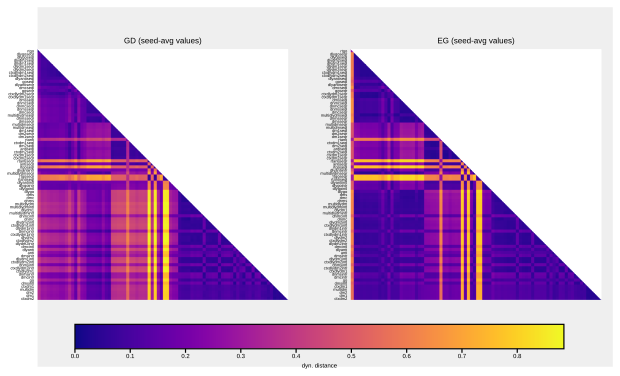

In [18]:
# Triangles with tasks sorted by EG vs GD mean distance (seed-averaged values).
if 'dsa' not in globals():
  raise RuntimeError("Run the DSA matrix cell first.")

# Task/seed order.
if 'task_order' in globals() and 'all_seeds' in globals():
  task_order_local = task_order
  seed_order_local = all_seeds
else:
  gd_pairs = [p for p in dsa.index if p[0] == 'gd']
  task_order_local = []
  seed_order_local = []
  for _, t, s in gd_pairs:
    if t not in task_order_local:
      task_order_local.append(t)
    if s not in seed_order_local:
      seed_order_local.append(s)

pair_to_idx = {pair: i for i, pair in enumerate(dsa.index)}

# Compute EG vs GD mean distance per task (across seeds) to sort tasks.
means = []
for t in task_order_local:
  vals = []
  for s in seed_order_local:
    p = ('gd', t, s)
    q = ('eg', t, s)
    if p in pair_to_idx and q in pair_to_idx:
      i = pair_to_idx[p]
      j = pair_to_idx[q]
      v = dsa.values[i, j]
      if np.isnan(v):
        v = dsa.values[j, i]
      if not np.isnan(v):
        vals.append(v)
  means.append(np.mean(vals) if vals else np.nan)

order_tasks = [t for _, t in sorted(zip(means, task_order_local), key=lambda x: (np.nan_to_num(x[0], nan=-np.inf)), reverse=True)]

num_tasks = len(task_order_local)
num_seeds = len(seed_order_local)

# Map to indices in the GD/EG blocks.
gd_block = dsa.iloc[:num_tasks*num_seeds, :num_tasks*num_seeds]
eg_block = dsa.iloc[num_tasks*num_seeds:, num_tasks*num_seeds:]

idx_map_gd = { (t,s): i for i, (_, t, s) in enumerate(gd_block.index) }
idx_map_eg = { (t,s): i for i, (_, t, s) in enumerate(eg_block.index) }

# Keep only pairs that exist in BOTH blocks to stay aligned.
order_pairs = [(t, s) for t in order_tasks for s in seed_order_local]
order_pairs = [(t, s) for (t, s) in order_pairs if (t, s) in idx_map_gd and (t, s) in idx_map_eg]

# Labels at ref seed.
ref_seed = 5 if 5 in seed_order_local else seed_order_local[0]
labels = [t if s == ref_seed else "" for (t, s) in order_pairs]
ticks = [i for i, lab in enumerate(labels) if lab]

# Seed-averaged task-level matrices.
def symmetrize(mat):
  mat = mat.copy()
  mat = np.where(np.isnan(mat), mat.T, mat)
  np.fill_diagonal(mat, 0.0)
  return mat

gd_full = symmetrize(gd_block.values)
eg_full = symmetrize(eg_block.values)

mat4_gd = gd_full.reshape(num_tasks, num_seeds, num_tasks, num_seeds)
mat4_eg = eg_full.reshape(num_tasks, num_seeds, num_tasks, num_seeds)

gd_task = np.nanmean(mat4_gd, axis=(1, 3))
eg_task = np.nanmean(mat4_eg, axis=(1, 3))

# Expand task-level matrices to seed-level (all seeds share the same task-pair value).
idx_task = {t: i for i, t in enumerate(task_order_local)}
order_task_idx = [idx_task[t] for (t, s) in order_pairs]

gd_exp = gd_task[np.ix_(order_task_idx, order_task_idx)]
eg_exp = eg_task[np.ix_(order_task_idx, order_task_idx)]

fig, axs = plt.subplots(1, 2, figsize=(8, 5), dpi=300)
render_background(fig)
fig.subplots_adjust(left=0.0, right=0.98, top=0.9, bottom=0.05, wspace=0.25)

vmin = 0.0
vmax = max(np.nanmax(gd_exp), np.nanmax(eg_exp))
tri_cmap = mpl.cm.get_cmap('plasma').copy()
tri_cmap.set_bad('white')

def plot_triangle_seedavg(ax, mat, title):
  mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
  mat_masked = np.ma.array(mat, mask=mask)
  im = ax.imshow(mat_masked, cmap=tri_cmap, vmin=vmin, vmax=vmax)
  ax.set_title(title, fontsize=8)
  ax.set_xticks([])
  ax.set_yticks(ticks)
  ax.set_yticklabels([labels[i] for i in ticks], va='top', fontsize=4)
  ax.tick_params(axis='y', length=0)
  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
  return im

im0 = plot_triangle_seedavg(axs[0], gd_exp, 'GD (seed-avg values)')
im1 = plot_triangle_seedavg(axs[1], eg_exp, 'EG (seed-avg values)')

cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.08, pad=0.08)
cbar.set_label('dyn. distance', fontsize=6)
cbar.ax.tick_params(labelsize=6, pad=1)


['Arial']


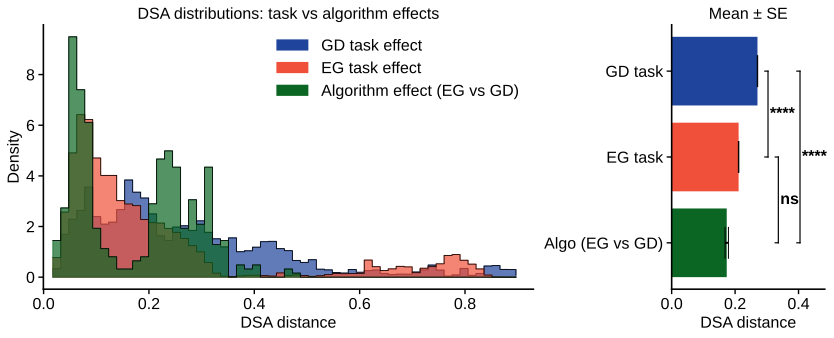

In [ ]:
# Histogram of DSA distributions: within-algorithm (triangles) vs cross-algorithm diagonal.
# Triangles capture task variability within the same algorithm; diagonal captures algorithm effect for same task/seed.

if 'dsa' not in globals():
  raise RuntimeError("Run the DSA matrix cell first.")

def apply_hist_fig1a_style(font_family=None):
  """Local Fig1a-style for this histogram cell only."""
  ff = font_family or plt.rcParams.get('font.family')
  ff_list = [ff] if isinstance(ff, str) else ff
  if ff_list:
    plt.rcParams['font.family'] = ff_list
    plt.rcParams['font.sans-serif'] = ff_list
  plt.rcParams.update({
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.6,
    'lines.linewidth': 2.0,
    'xtick.major.width': 1.4,
    'ytick.major.width': 1.4,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    # 'font.weight': 'bold',
    # 'axes.labelweight': 'bold',
    # 'axes.titleweight': 'bold',
  })

apply_hist_fig1a_style(font_family=font_family)

# Ensure task/seed info.
if 'task_order' in globals() and 'all_seeds' in globals():
  task_order_local = task_order
  seed_order_local = all_seeds
else:
  gd_pairs = [p for p in dsa.index if p[0] == 'gd']
  task_order_local = []
  seed_order_local = []
  for _, t, s in gd_pairs:
    if t not in task_order_local:
      task_order_local.append(t)
    if s not in seed_order_local:
      seed_order_local.append(s)

num_tasks = len(task_order_local)
num_seeds = len(seed_order_local)
num_per_model = num_tasks * num_seeds

gd_block = dsa.iloc[:num_per_model, :num_per_model]
eg_block = dsa.iloc[num_per_model:, num_per_model:]

# Extract lower triangles (exclude diagonal).
def lower_triangle_vals(mat):
  arr = np.array(mat, dtype=float)
  tri = np.tril(arr, k=-1)
  return tri[~np.isnan(tri)].ravel()

gd_vals = lower_triangle_vals(gd_block.values)
eg_vals = lower_triangle_vals(eg_block.values)

# Drop exact zeros (e.g., diagonal entries if they slip in).
gd_vals = gd_vals[gd_vals != 0]
eg_vals = eg_vals[eg_vals != 0]

# Cross-algorithm diagonal: same task/seed, EG vs GD.
pair_to_idx = {pair: i for i, pair in enumerate(dsa.index)}

cross_vals = []
for t in task_order_local:
  for s in seed_order_local:
    p = ('eg', t, s)
    q = ('gd', t, s)
    if p in pair_to_idx and q in pair_to_idx:
      i = pair_to_idx[p]
      j = pair_to_idx[q]
      v = dsa.values[i, j]
      if np.isnan(v):
        v = dsa.values[j, i]
      if not np.isnan(v):
        cross_vals.append(v)

cross_vals = np.array(cross_vals)
# Drop exact zeros (if any).
cross_vals = cross_vals[cross_vals != 0]

# Mann-Whitney U tests (two-sided), with Holm correction.
from scipy.stats import mannwhitneyu

def safe_mwu(a, b):
  if len(a) == 0 or len(b) == 0:
    return np.nan
  return mannwhitneyu(a, b, alternative='two-sided').pvalue

def holm_correction(pvals):
  m = len(pvals)
  order = np.argsort(pvals)
  adj = np.empty(m)
  for i, idx in enumerate(order):
    adj[idx] = min((m - i) * pvals[idx], 1.0)
  # enforce monotonicity
  for i in range(1, m):
    prev = order[i - 1]
    curr = order[i]
    if adj[curr] < adj[prev]:
      adj[curr] = adj[prev]
  return adj

def p_to_stars(p):
  if np.isnan(p):
    return 'n/a'
  if p < 1e-4:
    return '****'
  if p < 1e-3:
    return '***'
  if p < 1e-2:
    return '**'
  if p < 0.05:
    return '*'
  return 'ns'

comparisons = [
  ('GD vs EG', gd_vals, eg_vals),
  ('GD vs Algo', gd_vals, cross_vals),
  ('EG vs Algo', eg_vals, cross_vals),
]

pvals = np.array([safe_mwu(a, b) for _, a, b in comparisons], dtype=float)
pvals_holm = holm_correction(pvals)

# Plot histogram + mean/std panel.
fig, axs = plt.subplots(1, 2, figsize=(11.69, 4.8), dpi=300, gridspec_kw={'width_ratios': [3.2, 1]})
fig.set_facecolor("white")
for ax in axs:
  ax.set_facecolor("white")
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.18, wspace=0.35)

all_vals = np.concatenate([gd_vals, eg_vals, cross_vals])
all_vals = all_vals[np.isfinite(all_vals)]

if all_vals.size > 0:
  bins = np.linspace(all_vals.min(), all_vals.max(), 60)
else:
  bins = 60

# Manual histogram fill to remove bin seams
hg, edges = np.histogram(gd_vals, bins=bins, density=True)
he, _ = np.histogram(eg_vals, bins=bins, density=True)
hc, _ = np.histogram(cross_vals, bins=bins, density=True)

axs[0].fill_between(edges[:-1], hg, step='post', color='#1f449c', alpha=.7, label='GD task effect', zorder=1)
axs[0].fill_between(edges[:-1], he, step='post', color='#f05039', alpha=.7, label='EG task effect', zorder=2)
axs[0].fill_between(edges[:-1], hc, step='post', color='#0b6623', alpha=.7, label='Algorithm effect (EG vs GD)', zorder=3)

# Outer black outlines only



axs[0].step(edges[:-1], hg, where='post', color='black', linewidth=0.8, zorder=1.1)
axs[0].step(edges[:-1], he, where='post', color='black', linewidth=0.8, zorder=2.1)
axs[0].step(edges[:-1], hc, where='post', color='black', linewidth=0.8, zorder=3.1)

axs[0].set_xlabel('DSA distance', fontsize=16)
axs[0].set_ylabel('Density', fontsize=16)
# axs[0].set_yscale('log')
axs[0].set_title('DSA distributions: task vs algorithm effects', fontsize=16)

import matplotlib.patches as mpatches
legend_handles = [
  mpatches.Patch(facecolor='#1f449c', edgecolor='none', label='GD task effect'),
  mpatches.Patch(facecolor='#f05039', edgecolor='none', label='EG task effect'),
  mpatches.Patch(facecolor='#0b6623', edgecolor='none', label='Algorithm effect (EG vs GD)')
]
axs[0].legend(handles=legend_handles, frameon=False, fontsize=16, loc='upper right')
axs[0].tick_params(axis='both', which='major', labelsize=16)
# Keep histogram within axes bounds.
if all_vals.size > 0:
  pad = 0.02 * (all_vals.max() - all_vals.min()) if all_vals.max() > all_vals.min() else 0.01
  axs[0].set_xlim(all_vals.min() - pad, all_vals.max() + pad)


labels = ['GD task', 'EG task', 'Algo (EG vs GD)']
vals = [gd_vals, eg_vals, cross_vals]
means = [np.mean(v) if len(v) else np.nan for v in vals]
ses = [np.std(v, ddof=1) / np.sqrt(len(v)) if len(v) > 1 else np.nan for v in vals]
colors = ['#1f449c', '#f05039', '#0b6623']

y = np.arange(len(labels))
axs[1].barh(y, means, xerr=ses, color=colors, capsize=16)
axs[1].set_yticks(y)
axs[1].set_yticklabels(labels, fontsize=16)
axs[1].set_xlabel('DSA distance', fontsize=16)
axs[1].set_title('Mean ± SE', fontsize=16)
axs[1].invert_yaxis()
axs[1].tick_params(axis='x', which='major', labelsize=16)

# Ensure summary panel fits error bars.
if np.any(np.isfinite(means)):
  max_mean = np.nanmax(means)
  max_se = np.nanmax(ses)
  if np.isfinite(max_mean) and np.isfinite(max_se):
    axs[1].set_xlim(0, max_mean + 1.2 * max_se)



# Pairwise Mann-Whitney tests between all three conditions.
pair_defs = [((0, 1), 'GD vs EG', gd_vals, eg_vals),
             ((1, 2), 'EG vs Algo', eg_vals, cross_vals),
             ((0, 2), 'GD vs Algo', gd_vals, cross_vals)]

pair_p = [safe_mwu(a, b) for _, _, a, b in pair_defs]
pair_stars = [p_to_stars(p) for p in pair_p]

# Draw bracket-style annotations to the right of bars.
max_x = np.nanmax([m + (s if np.isfinite(s) else 0) for m, s in zip(means, ses)])
if not np.isfinite(max_x):
  max_x = 0.0
spacing = max(0.02, 0.12 * max_x)
cap = max(0.01, 0.02 * max_x)

# Extend x-limits to fit brackets.
axs[1].set_xlim(0, max_x + spacing * (len(pair_defs) + 3.5))

for i, ((y1, y2), _, _, _), star in zip(range(len(pair_defs)), pair_defs, pair_stars):
  extra = spacing * 1.1 if i == 2 else 0.0
  x = max_x + spacing * (i + 1) + extra
  # vertical connector
  axs[1].plot([x, x], [y1, y2], color='black', lw=1.2)
  # caps
  axs[1].plot([x - cap, x], [y1, y1], color='black', lw=1.2)
  axs[1].plot([x - cap, x], [y2, y2], color='black', lw=1.2)
  # star label
  axs[1].text(x + cap * 0.6, (y1 + y2) / 2, star, va='center', ha='left', fontsize=16, fontweight='bold')

fig.tight_layout()

print(plt.rcParams['font.family'])

plt.savefig('figs/mod_cog_dsa_dsa_histogram_colorbar_boundary.pdf', bbox_inches='tight', transparent=True)
plt.savefig('figs/mod_cog_dsa_dsa_histogram_colorbar_boundary.svg', bbox_inches='tight', transparent=True)
plt.show()



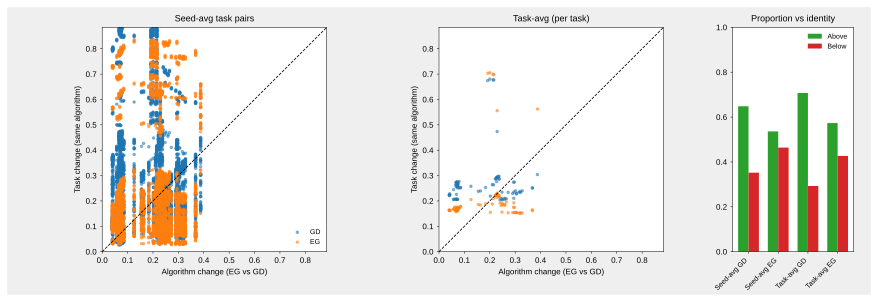

In [5]:
# Scatter: algorithm change vs task change.
# x = EG vs GD distance (same task/seed), y = task change (same algorithm/seed).

if 'dsa' not in globals():
  raise RuntimeError("Run the DSA matrix cell first.")

# Task/seed order.
if 'task_order' in globals() and 'all_seeds' in globals():
  task_order_local = task_order
  seed_order_local = all_seeds
else:
  gd_pairs = [p for p in dsa.index if p[0] == 'gd']
  task_order_local = []
  seed_order_local = []
  for _, t, s in gd_pairs:
    if t not in task_order_local:
      task_order_local.append(t)
    if s not in seed_order_local:
      seed_order_local.append(s)

pair_to_idx = {pair: i for i, pair in enumerate(dsa.index)}

def get_dsa(pair_a, pair_b):
  i = pair_to_idx.get(pair_a)
  j = pair_to_idx.get(pair_b)
  if i is None or j is None:
    return np.nan
  v = dsa.values[i, j]
  if np.isnan(v):
    v = dsa.values[j, i]
  return v

# Algorithm change per task (averaged across seeds).
x_task = {}
for t in task_order_local:
  vals = []
  for s in seed_order_local:
    v = get_dsa(('gd', t, s), ('eg', t, s))
    if not np.isnan(v):
      vals.append(v)
  x_task[t] = np.mean(vals) if vals else np.nan

# Variant 1: task-pair points (averaged across seeds).
points_v1 = {'gd': [], 'eg': []}
ys_by_task = {'gd': {t: [] for t in task_order_local}, 'eg': {t: [] for t in task_order_local}}

for alg in ['gd', 'eg']:
  for t in task_order_local:
    x = x_task.get(t, np.nan)
    if np.isnan(x):
      continue
    for t2 in task_order_local:
      if t2 == t:
        continue
      vals = []
      for s in seed_order_local:
        v = get_dsa((alg, t, s), (alg, t2, s))
        if not np.isnan(v):
          vals.append(v)
      if vals:
        y = np.mean(vals)
        points_v1[alg].append((x, y))
        ys_by_task[alg][t].append(y)

# Variant 2: per-task points (task change averaged across other tasks).
points_v2 = {'gd': [], 'eg': []}
for alg in ['gd', 'eg']:
  for t in task_order_local:
    x = x_task.get(t, np.nan)
    ys = ys_by_task[alg].get(t, [])
    if np.isnan(x) or not ys:
      continue
    points_v2[alg].append((x, float(np.mean(ys))))

# Shared axis limits.
def max_xy(points_dict):
  vals = []
  for pts in points_dict.values():
    for x, y in pts:
      if np.isfinite(x) and np.isfinite(y):
        vals.append(max(x, y))
  return max(vals) if vals else 1.0

max_all = max(max_xy(points_v1), max_xy(points_v2))

# Count above/below identity.
def count_above_below(points_list):
  above = 0
  below = 0
  for x, y in points_list:
    if not np.isfinite(x) or not np.isfinite(y):
      continue
    if y > x:
      above += 1
    elif y < x:
      below += 1
  return above, below

counts = {}
for alg in ['gd', 'eg']:
  counts[(alg, 'seed')] = count_above_below(points_v1[alg])
  counts[(alg, 'task')] = count_above_below(points_v2[alg])

fig = plt.figure(figsize=(12, 4), dpi=300)
render_background(fig)

# Scatter panels.
ax1 = fig.add_axes([0.06, 0.15, 0.36, 0.78])
ax2 = fig.add_axes([0.45, 0.15, 0.36, 0.78])
ax3 = fig.add_axes([0.84, 0.15, 0.14, 0.78])

colors = {'gd': '#1f77b4', 'eg': '#ff7f0e'}

def plot_panel(ax, points, title, show_legend=False):
  for alg in ['gd', 'eg']:
    pts = np.array(points[alg], dtype=float)
    if pts.size:
      ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5, color=colors[alg], label=alg.upper())
  ax.plot([0, max_all], [0, max_all], 'k--', lw=0.8)
  ax.set_xlim([0, max_all])
  ax.set_ylim([0, max_all])
  ax.set_aspect('equal', adjustable='box')
  ax.set_title(title, fontsize=9)
  ax.set_xlabel('Algorithm change (EG vs GD)')
  ax.set_ylabel('Task change (same algorithm)')
  if show_legend:
    ax.legend(frameon=False, fontsize=7)

plot_panel(ax1, points_v1, 'Seed-avg task pairs', show_legend=True)
plot_panel(ax2, points_v2, 'Task-avg (per task)', show_legend=False)

# Bar panel: above/below proportions by algorithm.
labels = ['Seed-avg GD', 'Seed-avg EG', 'Task-avg GD', 'Task-avg EG']
above = np.array([counts[('gd','seed')][0], counts[('eg','seed')][0], counts[('gd','task')][0], counts[('eg','task')][0]], dtype=float)
below = np.array([counts[('gd','seed')][1], counts[('eg','seed')][1], counts[('gd','task')][1], counts[('eg','task')][1]], dtype=float)
total = np.maximum(above + below, 1.0)
above_p = above / total
below_p = below / total

x = np.arange(len(labels))
width = 0.35
ax3.bar(x - width/2, above_p, width, color='#2ca02c', label='Above')
ax3.bar(x + width/2, below_p, width, color='#d62728', label='Below')
ax3.set_ylim([0, 1])
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax3.set_title('Proportion vs identity', fontsize=9)
ax3.legend(frameon=False, fontsize=7)
